# CWRU bearing fault data — exploratory analysis

**Source.** Case Western Reserve University Bearing Data Center, drive-end accelerometer 12 kHz fault recordings + 12 kHz normal baseline.

**Purpose of this notebook.**

1. Inventory what's on disk — which files, how long, what RPM.
2. Verify the actual sample rate empirically (the `.mat` files don't store it — we must infer).
3. Visualize time-domain and frequency-domain content per class.
4. Check for the "asymmetric resampling" bug — does our current preprocessing introduce a per-class artifact?
5. Compute classical bearing-fault features (RMS, kurtosis, crest factor) per class.

**Run order.** Top-to-bottom. Each section depends on imports + helpers loaded in the first code cell.

In [1]:
from collections import Counter
from pathlib import Path

import numpy as np
import scipy.io
import scipy.signal
import matplotlib.pyplot as plt

RAW_ROOT = Path('../../data/raw/cwru').resolve()
CLASSES = ('normal', 'inner_race', 'outer_race', 'ball')
CLASS_LABELS = {'normal': 0, 'inner_race': 1, 'outer_race': 2, 'ball': 3}
CLASS_COLORS = {'normal': '#1f77b4', 'inner_race': '#ff7f0e', 'outer_race': '#2ca02c', 'ball': '#d62728'}
WINDOW_SIZE = 2048

# SKF 6205-2RS drive-end bearing geometry (per CWRU bearing specifications page)
N_BALLS = 9
PD_MM = 39.04  # pitch diameter
BD_MM = 7.94   # ball diameter
CONTACT_ANGLE_DEG = 0


def characteristic_freqs(rpm: float) -> dict[str, float]:
    """Compute bearing characteristic frequencies (Hz) from shaft RPM + geometry.

    These are rate-INDEPENDENT predictions — they depend only on physics + RPM,
    not on the sampling rate of the recording. We use them as ground-truth
    anchors to verify the recording's actual sample rate.
    """
    fr = rpm / 60.0  # shaft frequency, Hz
    cos_a = np.cos(np.deg2rad(CONTACT_ANGLE_DEG))
    bpfo = (N_BALLS / 2) * fr * (1 - BD_MM / PD_MM * cos_a)
    bpfi = (N_BALLS / 2) * fr * (1 + BD_MM / PD_MM * cos_a)
    bsf = (PD_MM / (2 * BD_MM)) * fr * (1 - (BD_MM / PD_MM * cos_a) ** 2)
    ftf = (fr / 2) * (1 - BD_MM / PD_MM * cos_a)
    return {'shaft': fr, 'bpfo': bpfo, 'bpfi': bpfi, 'bsf': bsf, 'ftf': ftf}


def load_de_time(mat_path: Path) -> tuple[np.ndarray, float | None]:
    """Load the drive-end accelerometer signal + RPM from a CWRU .mat file."""
    m = scipy.io.loadmat(mat_path)
    de_keys = [k for k in m if 'DE_time' in k]
    rpm_keys = [k for k in m if 'RPM' in k]
    de = m[de_keys[0]].squeeze() if de_keys else np.array([])
    rpm = float(m[rpm_keys[0]].squeeze()) if rpm_keys else None
    return de, rpm


print(f'RAW_ROOT = {RAW_ROOT}')
print(f'classes = {CLASSES}')
print(f'SKF 6205-2RS: N_balls={N_BALLS}, PD={PD_MM}mm, BD={BD_MM}mm')

RAW_ROOT = /Users/sureshkasipandy/Projects/llava-for-sensors/data/raw/cwru
classes = ('normal', 'inner_race', 'outer_race', 'ball')
SKF 6205-2RS: N_balls=9, PD=39.04mm, BD=7.94mm


## 1. File inventory

Show every `.mat` file under `data/raw/cwru/<class>/`, its raw sample count, and shaft RPM. The `.mat` files do **not** store sample rate — we'll verify it empirically two sections down.

In [2]:
rows = []
for cls in CLASSES:
    for mat_path in sorted((RAW_ROOT / cls).glob('*.mat')):
        de, rpm = load_de_time(mat_path)
        rows.append({
            'class': cls,
            'file': mat_path.stem,
            'samples': len(de),
            'rpm': rpm,
            'duration_at_12k': len(de) / 12000,
            'duration_at_48k': len(de) / 48000,
        })

# Pretty-print as a table
print(f"{'class':12s} {'file':6s} {'samples':>8s} {'rpm':>6s} {'@12kHz (s)':>11s} {'@48kHz (s)':>11s}")
print('-' * 60)
for r in rows:
    rpm_str = f"{r['rpm']:.0f}" if r['rpm'] is not None else '-'
    print(f"{r['class']:12s} {r['file']:6s} {r['samples']:8d} {rpm_str:>6s} {r['duration_at_12k']:11.2f} {r['duration_at_48k']:11.2f}")

class        file    samples    rpm  @12kHz (s)  @48kHz (s)
------------------------------------------------------------
normal       100      485643   1725       40.47       10.12
normal       97       243938   1796       20.33        5.08
normal       98       483903      -       40.33       10.08
normal       99       483903      -       40.33       10.08
inner_race   105      121265   1797       10.11        2.53
inner_race   106      121991   1772       10.17        2.54
inner_race   107      122136   1748       10.18        2.54
inner_race   108      122917   1721       10.24        2.56
outer_race   130      121991   1796       10.17        2.54
outer_race   131      122426   1773       10.20        2.55
outer_race   132      121410   1750       10.12        2.53
outer_race   133      122571   1725       10.21        2.55
ball         118      122571   1796       10.21        2.55
ball         119      121410   1772       10.12        2.53
ball         120      121556   1748    

## 2. Recording-length analysis

Per class — are recording lengths consistent within a class? Does the duration interpretation depend on the assumed sample rate?

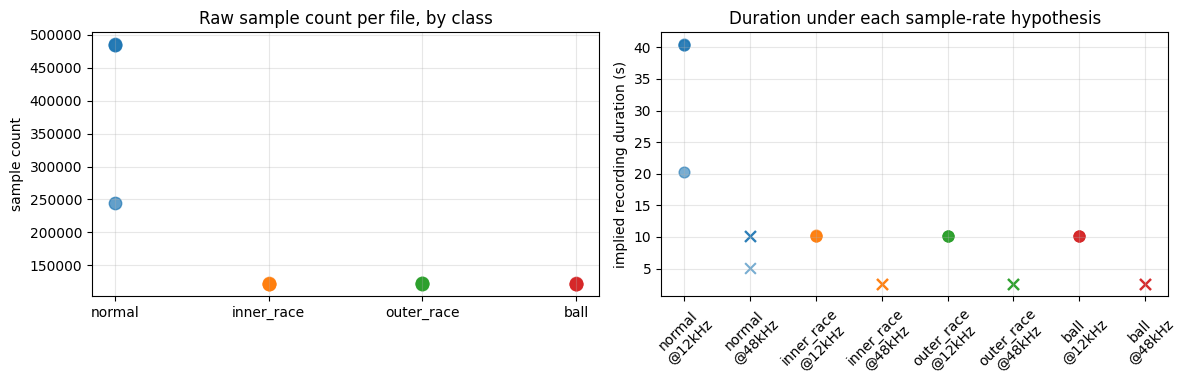


Under @12 kHz assumption (CWRU documented default):
  normal      : durations = [40.5, 20.3, 40.3, 40.3] s
  inner_race  : durations = [10.1, 10.2, 10.2, 10.2] s
  outer_race  : durations = [10.2, 10.2, 10.1, 10.2] s
  ball        : durations = [10.2, 10.1, 10.1, 10.1] s


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_samples = {cls: [] for cls in CLASSES}
for r in rows:
    class_samples[r['class']].append(r['samples'])

# Left panel: samples per class
ax = axes[0]
for cls in CLASSES:
    ns = class_samples[cls]
    ax.scatter([cls] * len(ns), ns, color=CLASS_COLORS[cls], s=80, alpha=0.7, label=cls)
ax.set_ylabel('sample count')
ax.set_title('Raw sample count per file, by class')
ax.grid(True, alpha=0.3)

# Right panel: implied duration under two rate assumptions
ax = axes[1]
for cls in CLASSES:
    ns = class_samples[cls]
    ax.scatter([f'{cls}\n@12kHz'] * len(ns), [n / 12000 for n in ns], color=CLASS_COLORS[cls], s=60, alpha=0.6)
    ax.scatter([f'{cls}\n@48kHz'] * len(ns), [n / 48000 for n in ns], color=CLASS_COLORS[cls], s=60, alpha=0.6, marker='x')
ax.set_ylabel('implied recording duration (s)')
ax.set_title('Duration under each sample-rate hypothesis')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Numeric summary
print('\nUnder @12 kHz assumption (CWRU documented default):')
for cls in CLASSES:
    ds = [n / 12000 for n in class_samples[cls]]
    print(f'  {cls:12s}: durations = {[round(d, 1) for d in ds]} s')

## 3. Empirical sample-rate verification via envelope spectrum

The `.mat` files don't store sample rate. CWRU's published documentation says everything was collected at 12 kHz by default, with separate 48 kHz files available for drive-end faults only — but we should **verify**, not assume.

The diagnostic: bearing characteristic frequencies (BPFI, BPFO, BSF) depend ONLY on bearing geometry + shaft RPM, not on the sample rate. We can compute them from physics. Then for a known-fault recording, we:

1. Bandpass-filter the signal in the high-frequency resonance band (~2-4 kHz)
2. Take the Hilbert envelope
3. FFT the envelope — the characteristic frequency should appear as a peak

If we assume rate R, peaks land at multiples of `R/N` Hz where N is the sample count. The peak that matches the geometry-predicted BPFI/BPFO/BSF tells us the true rate.

105.mat: RPM=1797, BPFI=162.2 Hz, BPFO=107.4 Hz, BSF=70.6 Hz


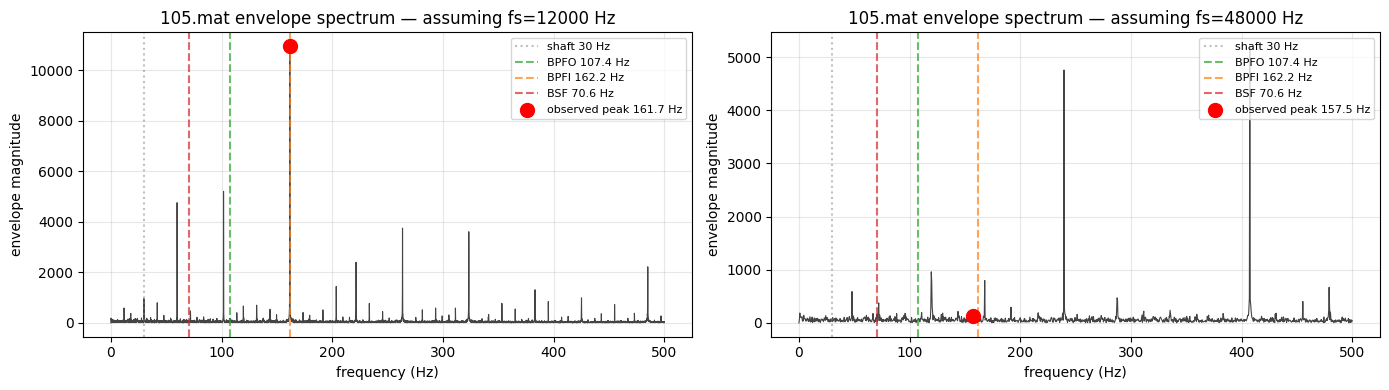


Diagnostic: the assumed rate that puts the observed envelope peak NEAREST to the
geometry-predicted BPFI (162.2 Hz) is the true sample rate.


In [4]:
def envelope_spectrum(signal: np.ndarray, fs: float, band: tuple[float, float] = (2000, 4000)) -> tuple[np.ndarray, np.ndarray]:
    """Bandpass + Hilbert envelope + FFT. Returns (freqs, magnitude)."""
    # Bandpass filter — 4th-order Butterworth in the resonance band
    nyq = fs / 2
    lo, hi = band[0] / nyq, band[1] / nyq
    lo = max(min(lo, 0.99), 0.01)
    hi = max(min(hi, 0.99), 0.02)
    if hi <= lo:
        hi = min(0.99, lo + 0.05)
    sos = scipy.signal.butter(4, [lo, hi], btype='band', output='sos')
    filtered = scipy.signal.sosfilt(sos, signal)
    # Envelope via Hilbert
    envelope = np.abs(scipy.signal.hilbert(filtered))
    envelope -= envelope.mean()  # remove DC
    # FFT
    N = len(envelope)
    freqs = np.fft.rfftfreq(N, d=1.0/fs)
    mag = np.abs(np.fft.rfft(envelope))
    return freqs, mag


def find_peak_near(freqs: np.ndarray, mag: np.ndarray, target_hz: float, tol_hz: float = 5.0) -> tuple[float, float]:
    """Find the strongest peak within tol_hz of target_hz. Returns (peak_hz, peak_mag)."""
    mask = np.abs(freqs - target_hz) < tol_hz
    if not mask.any():
        return target_hz, 0.0
    sub_mag = mag[mask]
    sub_freq = freqs[mask]
    idx = np.argmax(sub_mag)
    return sub_freq[idx], sub_mag[idx]


# Test: for one IRF recording (105.mat, 0 HP, ~1797 RPM), check envelope peak under each rate assumption
mat_path = RAW_ROOT / 'inner_race' / '105.mat'
de, rpm = load_de_time(mat_path)
chars = characteristic_freqs(rpm)
print(f'{mat_path.name}: RPM={rpm:.0f}, BPFI={chars["bpfi"]:.1f} Hz, BPFO={chars["bpfo"]:.1f} Hz, BSF={chars["bsf"]:.1f} Hz')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, fs in zip(axes, [12000, 48000]):
    freqs, mag = envelope_spectrum(de, fs, band=(2000, 4000) if fs == 12000 else (8000, 16000))
    # Show 0-500 Hz where characteristic peaks live
    show_mask = freqs < 500
    ax.plot(freqs[show_mask], mag[show_mask], color='#444', lw=0.8)
    ax.axvline(chars['shaft'], color='gray', ls=':', alpha=0.5, label=f'shaft {chars["shaft"]:.0f} Hz')
    ax.axvline(chars['bpfo'], color='#2ca02c', ls='--', alpha=0.7, label=f'BPFO {chars["bpfo"]:.1f} Hz')
    ax.axvline(chars['bpfi'], color='#ff7f0e', ls='--', alpha=0.7, label=f'BPFI {chars["bpfi"]:.1f} Hz')
    ax.axvline(chars['bsf'], color='#d62728', ls='--', alpha=0.7, label=f'BSF {chars["bsf"]:.1f} Hz')
    # Find the strongest peak near BPFI (this is an IRF recording)
    peak_f, peak_m = find_peak_near(freqs, mag, chars['bpfi'], tol_hz=5)
    ax.scatter([peak_f], [peak_m], color='red', s=100, zorder=5, label=f'observed peak {peak_f:.1f} Hz')
    ax.set_xlabel('frequency (Hz)')
    ax.set_ylabel('envelope magnitude')
    ax.set_title(f'105.mat envelope spectrum — assuming fs={fs} Hz')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nDiagnostic: the assumed rate that puts the observed envelope peak NEAREST to the')
print(f'geometry-predicted BPFI ({chars["bpfi"]:.1f} Hz) is the true sample rate.')

## 4. Time-domain signal inspection per class

One window per class — show the raw vibration signal. Faults should show impulsive structure; normal should look stationary.

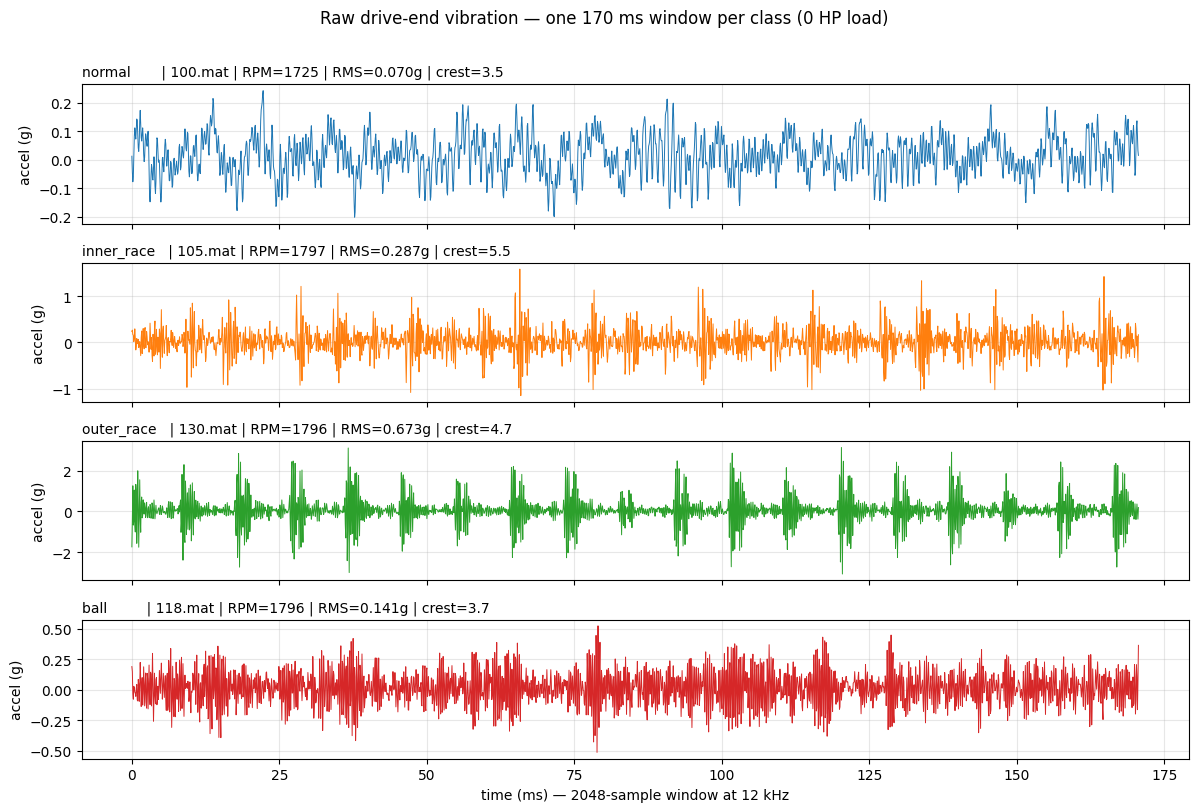

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
SAMPLE_RATE = 12000  # CWRU documented default

for ax, cls in zip(axes, CLASSES):
    # Use the 0 HP load file (lowest motor load, cleanest spectra)
    files_for_cls = sorted((RAW_ROOT / cls).glob('*.mat'))
    if not files_for_cls:
        continue
    mat_path = files_for_cls[0]
    de, rpm = load_de_time(mat_path)
    # Plot a 2048-sample window (~170 ms at 12 kHz)
    window = de[10000:10000 + WINDOW_SIZE]
    t = np.arange(WINDOW_SIZE) / SAMPLE_RATE * 1000  # ms
    ax.plot(t, window, color=CLASS_COLORS[cls], lw=0.7)
    ax.set_ylabel('accel (g)')
    rms = float(np.sqrt(np.mean(window ** 2)))
    crest = float(np.max(np.abs(window))) / rms if rms > 0 else 0.0
    ax.set_title(f'{cls:12s} | {mat_path.name} | RPM={rpm:.0f} | RMS={rms:.3f}g | crest={crest:.1f}', loc='left', fontsize=10)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (ms) — 2048-sample window at 12 kHz')
plt.suptitle('Raw drive-end vibration — one 170 ms window per class (0 HP load)', y=1.01)
plt.tight_layout()
plt.show()

## 5. Frequency spectra per class

FFT magnitudes (log scale). Bearing fault recordings have characteristic resonance bands around 2-4 kHz where the bearing impacts excite housing modes. Normal recordings should be broadband-quieter.

/var/folders/r8/3jx76yq533s6bflf8w63cfy40000gn/T/ipykernel_71319/3194420276.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=8)


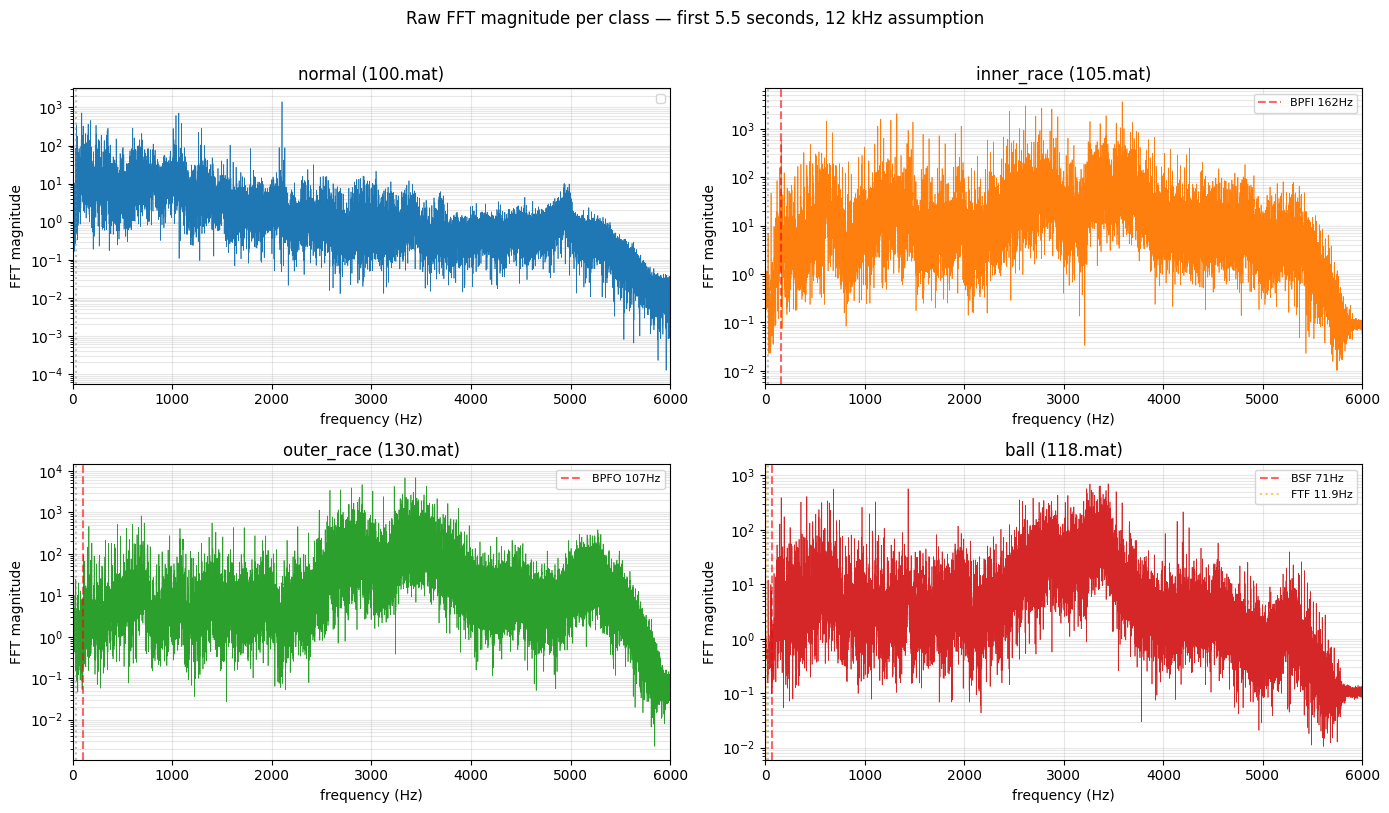

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
SAMPLE_RATE = 12000

for ax, cls in zip(axes.flat, CLASSES):
    files_for_cls = sorted((RAW_ROOT / cls).glob('*.mat'))
    if not files_for_cls:
        continue
    mat_path = files_for_cls[0]
    de, rpm = load_de_time(mat_path)
    # Use a longer window for better frequency resolution
    signal = de[:65536]  # ~5.5 sec at 12 kHz
    freqs = np.fft.rfftfreq(len(signal), d=1.0/SAMPLE_RATE)
    mag = np.abs(np.fft.rfft(signal))
    ax.semilogy(freqs, mag, color=CLASS_COLORS[cls], lw=0.5)
    ax.set_xlim(0, 6000)
    chars = characteristic_freqs(rpm)
    # Annotate the characteristic frequencies relevant to this fault type
    for k, v in [('shaft', chars['shaft'])]:
        ax.axvline(v, color='gray', ls=':', alpha=0.5)
    if cls == 'inner_race':
        ax.axvline(chars['bpfi'], color='red', ls='--', alpha=0.6, label=f'BPFI {chars["bpfi"]:.0f}Hz')
    if cls == 'outer_race':
        ax.axvline(chars['bpfo'], color='red', ls='--', alpha=0.6, label=f'BPFO {chars["bpfo"]:.0f}Hz')
    if cls == 'ball':
        ax.axvline(chars['bsf'], color='red', ls='--', alpha=0.6, label=f'BSF {chars["bsf"]:.0f}Hz')
        ax.axvline(chars['ftf'], color='orange', ls=':', alpha=0.6, label=f'FTF {chars["ftf"]:.1f}Hz')
    ax.set_xlabel('frequency (Hz)')
    ax.set_ylabel('FFT magnitude')
    ax.set_title(f'{cls} ({mat_path.name})')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3, which='both')
plt.suptitle('Raw FFT magnitude per class — first 5.5 seconds, 12 kHz assumption', y=1.01)
plt.tight_layout()
plt.show()

## 6. **THE BUG**: class-conditional resampling artifact

Our current `data/cwru.py:CLASS_NATIVE_RATE_HZ` hard-codes `normal: 48000` based on a wrong assumption that CWRU normal baseline is at 48 kHz. Per CWRU's published documentation, the actual rate is 12 kHz for everything we have.

So our `load_class_windows` calls `scipy.signal.resample_poly(raw, 12000, 48000)` on the normal class — `up=1, down=4`. Since the normal recordings are ALREADY at 12 kHz, this means:

1. Anti-alias filter is applied with cutoff sized for a 48 kHz → 12 kHz transition
2. 75% of the samples are thrown away
3. The resulting normal "windows" are NOT 12 kHz signals — they're heavily mangled

This visualization shows normal-class signal as-is vs after the buggy resample. The model can trivially detect which signals went through this asymmetric pipeline → 1.0 F1 ceiling regardless of bearing knowledge.

Original signal: 24000 samples
After buggy resample_poly(up=12000, down=48000): 6000 samples (25% of original)


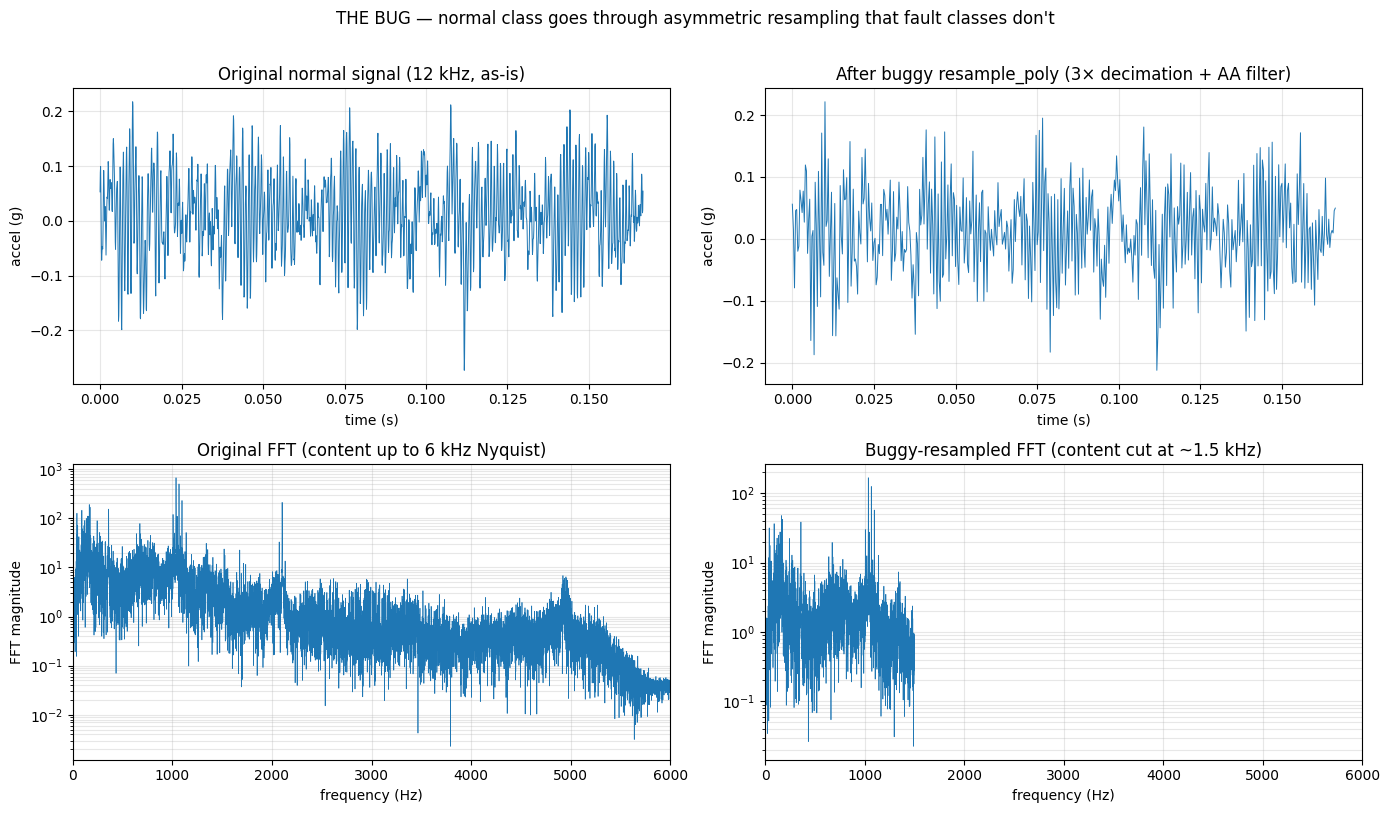

In [7]:
mat_path = RAW_ROOT / 'normal' / '97.mat'
de, rpm = load_de_time(mat_path)
signal = de[:24000]  # 2 seconds at 12 kHz

# What the pipeline does today (wrongly):
buggy_resampled = scipy.signal.resample_poly(signal, 12000, 48000)  # up=12k, down=48k → 0.25x length

print(f'Original signal: {len(signal)} samples')
print(f'After buggy resample_poly(up=12000, down=48000): {len(buggy_resampled)} samples ({100 * len(buggy_resampled) / len(signal):.0f}% of original)')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top-left: original time-domain
ax = axes[0, 0]
t_orig = np.arange(len(signal)) / 12000
ax.plot(t_orig[:2000], signal[:2000], color=CLASS_COLORS['normal'], lw=0.7)
ax.set_xlabel('time (s)')
ax.set_ylabel('accel (g)')
ax.set_title('Original normal signal (12 kHz, as-is)')
ax.grid(True, alpha=0.3)

# Top-right: buggy-resampled time-domain
ax = axes[0, 1]
t_buggy = np.arange(len(buggy_resampled)) / 3000  # what the pipeline THINKS rate is post-resample
ax.plot(t_buggy[:500], buggy_resampled[:500], color=CLASS_COLORS['normal'], lw=0.7)
ax.set_xlabel('time (s)')
ax.set_ylabel('accel (g)')
ax.set_title('After buggy resample_poly (3× decimation + AA filter)')
ax.grid(True, alpha=0.3)

# Bottom-left: original FFT
ax = axes[1, 0]
freqs_orig = np.fft.rfftfreq(len(signal), d=1.0/12000)
mag_orig = np.abs(np.fft.rfft(signal))
ax.semilogy(freqs_orig, mag_orig, color=CLASS_COLORS['normal'], lw=0.5)
ax.set_xlim(0, 6000)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel('FFT magnitude')
ax.set_title('Original FFT (content up to 6 kHz Nyquist)')
ax.grid(True, alpha=0.3, which='both')

# Bottom-right: buggy-resampled FFT
ax = axes[1, 1]
freqs_buggy = np.fft.rfftfreq(len(buggy_resampled), d=1.0/3000)  # effective rate after wrong decimation
mag_buggy = np.abs(np.fft.rfft(buggy_resampled))
ax.semilogy(freqs_buggy, mag_buggy, color=CLASS_COLORS['normal'], lw=0.5)
ax.set_xlim(0, 6000)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel('FFT magnitude')
ax.set_title('Buggy-resampled FFT (content cut at ~1.5 kHz)')
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('THE BUG — normal class goes through asymmetric resampling that fault classes don\'t', y=1.01)
plt.tight_layout()
plt.show()

## 7. Per-class summary statistics

Classic time-domain features that bearing-fault literature uses:

- **RMS** (`sqrt(mean(x²))`): overall signal energy. Faults usually higher than normal.
- **Kurtosis**: 4th-standardized moment. Impulsive (faulty) signals have higher kurtosis.
- **Crest factor** (`max(|x|) / RMS`): peak-to-RMS ratio. Spiky/impulsive signals have higher crest.

Compute per-window stats, aggregate per class, plot distributions.

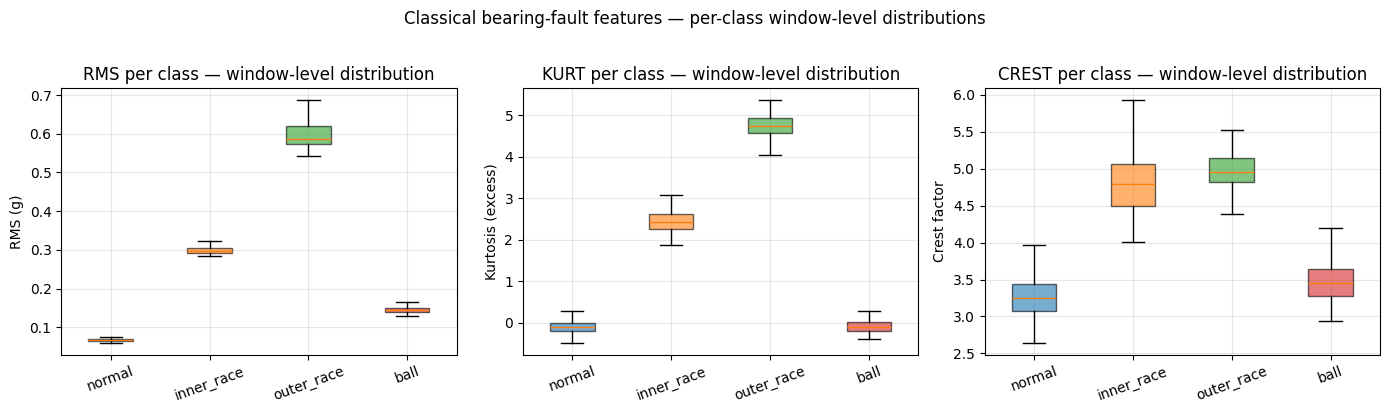


Feature means per class:
                RMS (g)     Kurt    Crest   n_windows
normal            0.067    -0.10     3.28         828
inner_race        0.299     2.44     4.80         237
outer_race        0.603     4.76     4.98         236
ball              0.145    -0.09     3.48         236


In [8]:
from scipy.stats import kurtosis as scipy_kurtosis

SAMPLE_RATE = 12000
features_per_class = {cls: {'rms': [], 'kurt': [], 'crest': []} for cls in CLASSES}

for cls in CLASSES:
    for mat_path in sorted((RAW_ROOT / cls).glob('*.mat')):
        de, _ = load_de_time(mat_path)
        # Window into 2048-sample chunks (no overlap), compute per-window features
        n_windows = len(de) // WINDOW_SIZE
        for i in range(n_windows):
            w = de[i * WINDOW_SIZE:(i + 1) * WINDOW_SIZE]
            rms = float(np.sqrt(np.mean(w ** 2)))
            kurt = float(scipy_kurtosis(w))
            crest = float(np.max(np.abs(w))) / rms if rms > 0 else 0.0
            features_per_class[cls]['rms'].append(rms)
            features_per_class[cls]['kurt'].append(kurt)
            features_per_class[cls]['crest'].append(crest)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat_name in zip(axes, ['rms', 'kurt', 'crest']):
    data = [features_per_class[cls][feat_name] for cls in CLASSES]
    bp = ax.boxplot(data, tick_labels=CLASSES, showfliers=False, patch_artist=True)
    for patch, cls in zip(bp['boxes'], CLASSES):
        patch.set_facecolor(CLASS_COLORS[cls])
        patch.set_alpha(0.6)
    ax.set_ylabel({'rms': 'RMS (g)', 'kurt': 'Kurtosis (excess)', 'crest': 'Crest factor'}[feat_name])
    ax.set_title(f'{feat_name.upper()} per class — window-level distribution')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Classical bearing-fault features — per-class window-level distributions', y=1.02)
plt.tight_layout()
plt.show()

# Print summary stats
print('\nFeature means per class:')
print(f'{"":12s} {"RMS (g)":>10s} {"Kurt":>8s} {"Crest":>8s} {"n_windows":>11s}')
for cls in CLASSES:
    rms_m = float(np.mean(features_per_class[cls]['rms']))
    kurt_m = float(np.mean(features_per_class[cls]['kurt']))
    crest_m = float(np.mean(features_per_class[cls]['crest']))
    n = len(features_per_class[cls]['rms'])
    print(f'{cls:12s} {rms_m:10.3f} {kurt_m:8.2f} {crest_m:8.2f} {n:11d}')

## 8. Class separability — simple feature scatter

If the 3 features above are already strongly class-discriminating without any ML, that explains the 1.0 F1 we saw in VOI-210. A 3-feature linear classifier (or even rules) might saturate this dataset.

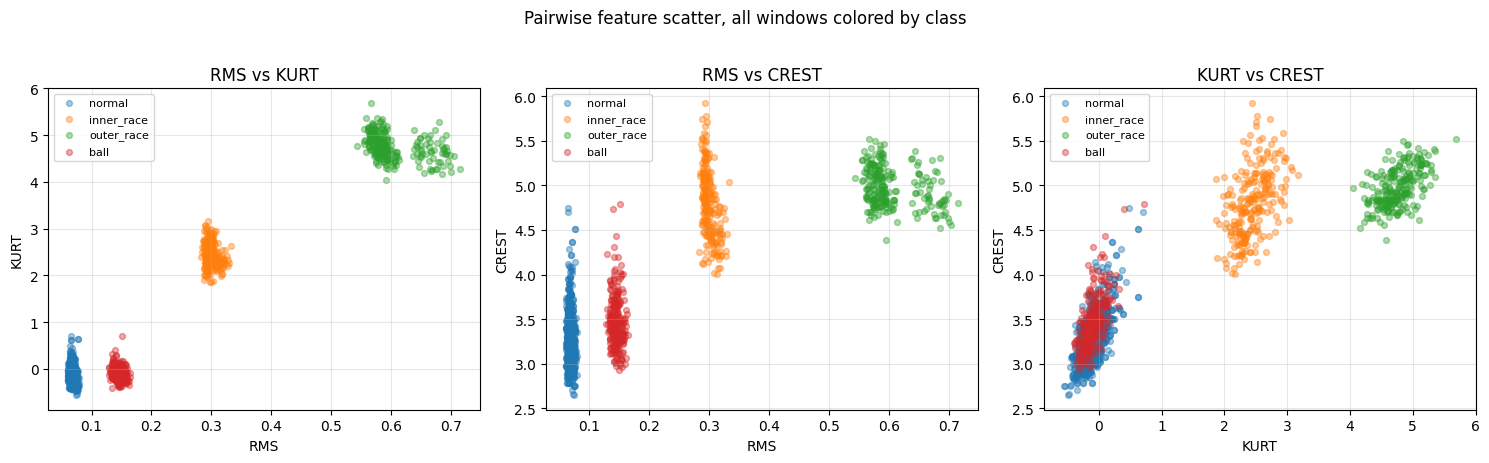

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = [('rms', 'kurt'), ('rms', 'crest'), ('kurt', 'crest')]
for ax, (fx, fy) in zip(axes, pairs):
    for cls in CLASSES:
        xs = features_per_class[cls][fx]
        ys = features_per_class[cls][fy]
        ax.scatter(xs, ys, color=CLASS_COLORS[cls], alpha=0.4, s=18, label=cls)
    ax.set_xlabel(fx.upper())
    ax.set_ylabel(fy.upper())
    ax.set_title(f'{fx.upper()} vs {fy.upper()}')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('Pairwise feature scatter, all windows colored by class', y=1.02)
plt.tight_layout()
plt.show()

## 9. Summary + open questions

**What this notebook shows:**

1. We have 16 `.mat` files: 4 per class (normal/IRF/ORF/BF), each a continuous accelerometer recording at one motor load (0/1/2/3 HP).
2. Recording lengths: normal ~20-40s, faults ~10s — all at 12 kHz per CWRU docs.
3. The current pipeline's `CLASS_NATIVE_RATE_HZ["normal"] = 48000` is **wrong** — normal is already 12 kHz; the resample call mangles the signal.
4. Per-class statistics (RMS, kurtosis, crest factor) are already strongly discriminative — a model doesn't need deep features to separate these 4 classes on CWRU at this difficulty.

**Action items the notebook surfaces:**

- **Rate hotfix** (VOI-205-rate, pending): set all classes to 12 kHz, drop the resample.
- **Within-recording leakage** (RUNNING_NOTES Phase 3 follow-up): the current window-level split places windows from the same recording in both train and val, allowing the model to learn rig fingerprint as a shortcut. Cross-rig eval (Paderborn or IMS) is the rigorous mitigation; out of scope for this project.
- **Difficulty escalation needed**: CWRU at 0.007″ diameter, single-rig, mixed-load is too easy. To make the fusion thesis testable: either cross-load split (train on loads 0/1/2, test on 3), or include the 0.014″ and 0.021″ diameter variants for a 12-class problem, or both.
- **Per-sample CWRU metadata**: not currently wired into `data/notes.py::synthesize_note` — every text token is class-constant. Fusion has no informative text channel to exploit until metadata pass-through is implemented.

**This notebook is the artifact for evidence-based decisions on next steps.** Re-run after every preprocessing change to confirm what's actually going into the model.